In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [2]:
dataset=load_diabetes()

In [3]:
df=pd.DataFrame(dataset.data, columns=dataset.feature_names)

In [4]:
df["target"]=dataset.target

In [5]:
# df boyutu
print(df.shape)
# DataFrame'de boş veri var mı ?
print(df.isnull().sum())
# DataFrame ilk 5 satır
print(df.head())

(442, 11)
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64
        age       sex       bmi        bp        s1        s2        s3        s4        s5        s6  target
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401 -0.002592  0.019907 -0.017646   151.0
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412 -0.039493 -0.068332 -0.092204    75.0
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356 -0.002592  0.002861 -0.025930   141.0
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038  0.034309  0.022688 -0.009362   206.0
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142 -0.002592 -0.031988 -0.046641   135.0


In [6]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [7]:
target_corr=df.corr()['target'].sort_values(ascending=False) # target sütununun diğer sütunlarla arasındaki korelasyon ilişkilerini büyükten küçüğe hesapladık.

In [8]:
print(target_corr)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


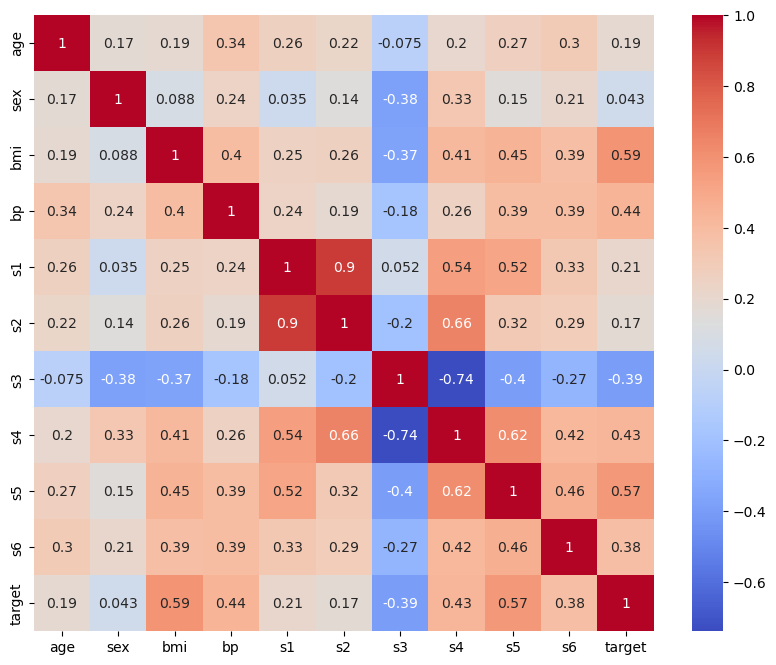

In [9]:
# sns.heatmap(tüm korelasyon matrisi -> df.corr(), annot=True (hücrelerin içine sayıları yazar), cmap='coolwarm' (renk paleti))
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

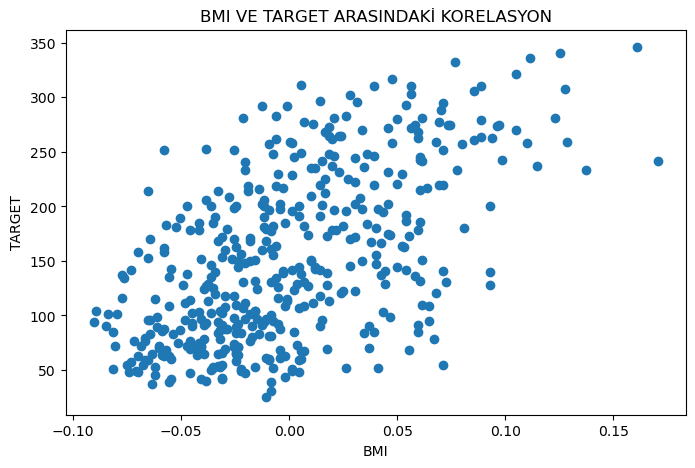

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['bmi'],df['target'])
plt.xlabel('BMI')
plt.ylabel('TARGET')
plt.title('BMI VE TARGET ARASINDAKİ KORELASYON')
plt.savefig('bmi ve target arasındaki korelasyon.png')
plt.show()

In [11]:
# BMI arttığında hastalık ilerleme skoru da artma eğilimindedir, bu ilişki orta-güçlü düzeyde pozitiftir (r=0.58)."

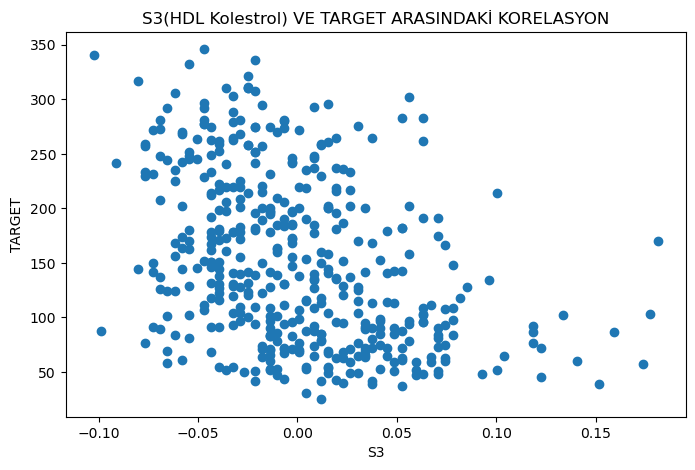

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df['s3'],df['target'])
plt.xlabel('S3')
plt.ylabel('TARGET')
plt.title('S3(HDL Kolestrol) VE TARGET ARASINDAKİ KORELASYON')
plt.savefig('s3 ve target arasındaki korelasyon.png')
plt.show()

In [13]:
# "S3 arttığında hastalık ilerleme skoru azalma eğilimindedir, bu ilişki orta-güçlü düzeyde negatiftir (r=-0.39)."

In [14]:
# Veriyi bölme
from sklearn.model_selection import train_test_split # gerekli fonksiyonu import etme
# Train / Test split
X=df[['bmi']]
y=df['target']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2 ,random_state=42) # random_state -> her adımda verilerin aynı biçimde çekilmesini sağlar.
# test_size = verilerin yüzde 20si modelin doğruluğunu test etmede kullanılacak.

In [15]:
from sklearn.linear_model import LinearRegression
# Model nesnesi oluşturma 
linear_model=LinearRegression()

In [16]:
# modeli eğit
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# y= mx+b formülündeki değerler i bulalım
print(f'm = (eğim) {linear_model.coef_} ')
print(f'b = (x 0 iken y yi kestiği nokta) {linear_model.intercept_}')

m = (eğim) [998.57768914] 
b = (x 0 iken y yi kestiği nokta) 152.00335421448167


In [18]:
# Tahmin 
y_pred=linear_model.predict(X_test)

In [19]:
# modelimiz ne kadar başarılı
from sklearn.metrics import r2_score, mean_squared_error # gerekli fonksiyonlar 
import numpy as np # gerekli fonksiyonlar
print(f"r2 score : {r2_score(y_test, y_pred)}")
np.sqrt(mean_squared_error(y_test, y_pred))

r2 score : 0.23335039815872138


np.float64(63.73245584860925)

In [20]:
# R² (R-kare): Modelin hedef değişkeni ne kadar iyi açıkladığını gösterir. 0 ile 1 arasında değer alır. 0.23 → model verinin %23'ünü açıklıyor, geri kalan %77 modelin yakalayamadığı başka faktörler.
# MSE (Mean Squared Error): Tahminlerin gerçek değerlerden ne kadar saptığını ölçer. Her hatayı kareler, ortalamasını alır. Karesi neden? Negatif ve pozitif hataların birbirini sıfırlamaması için.
# Neden karekök aldık?
# MSE'nin birimi skor² oluyor, yani anlamsız. Karekök alınca RMSE elde ediyoruz ve birimi tekrar skor oluyor. Yani "modelim ortalamada 63.7 skor yanılıyor" diyebiliyoruz — bu çok daha yorumlanabilir!

C:\Users\asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


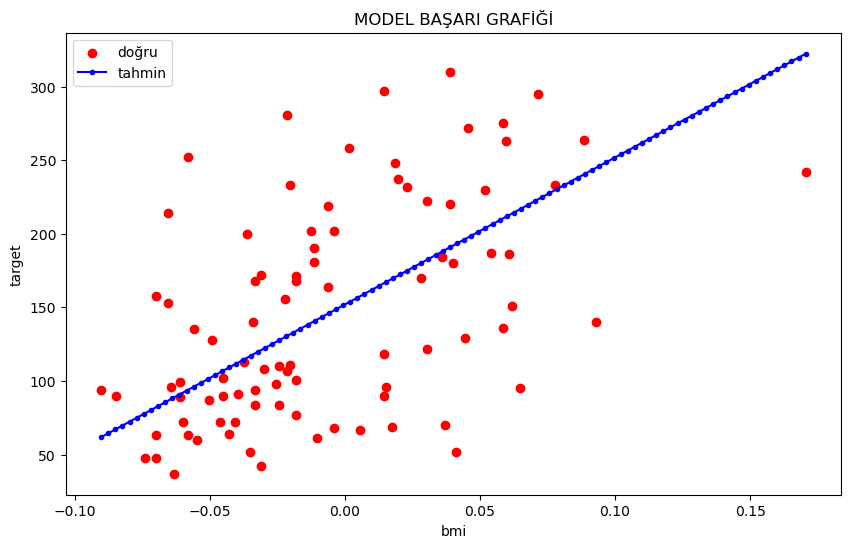

In [21]:
# yorum grafiği
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, c='red', label='doğru') # gerçek noktalar
x_line=np.linspace(X_test.min(), X_test.max(), 100).reshape(-1,1)
y_line=linear_model.predict(x_line)
plt.plot(x_line, y_line, color='blue', marker='.', label='tahmin') # regresyon doğrusu
plt.xlabel('bmi')
plt.ylabel('target')
plt.title('MODEL BAŞARI GRAFİĞİ')
plt.legend()
plt.savefig("model_basari_grafigi.png")
plt.show()

### noktaların çizgiden uzaklaşması modelimizin başarısızlığını gösteriyor !!! ama bazı tahminler de çizgi ile çakışıyor yani modelimiz güzel tahminler de yapmış.

In [22]:
X_Multi=df.drop('target', axis=1) 
#  orijinal df değişmez. drop() yeni bir DataFrame döndürür, df'den target sütununu çıkarmış hali.

In [23]:
y=df['target']

In [24]:
# Verilerimizi bölelim
X_Multi_train, X_Multi_test, y_train, y_test = train_test_split(X_Multi, y, test_size=0.2, random_state=42)

In [25]:
# model nesnesi oluşturma
multi_model=LinearRegression()

In [26]:
# oluşturduğumuz bu modeli eğitme
multi_model.fit(X_Multi_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
# eğittimiz model ile tahmin yapma
y_multi_pred=multi_model.predict(X_Multi_test) # X_Multi_test sorularını aldığın eğitim üzerine çözmeye çalış sonuçları y_multi_pred in içine koy !!.

In [28]:
# modelimizin başarısını ölçelim !!!!
print(f'Modelimizin r2 scoru : {r2_score(y_test, y_multi_pred)}')
print(f'Modelimizin RMSE"E si : {np.sqrt(mean_squared_error(y_test, y_multi_pred))} ')

Modelimizin r2 scoru : 0.4526027629719195
Modelimizin RMSE"E si : 53.85344583676593 


##### tüm featureler ile modelimiz hastalık ilerleme skorunun yüzde 45 ini elindeki verilerle açıklıyor ve tüm özellikler ile modelimiz daha az hata yapıyor

#####  R² 0.23'ten 0.45'e çıktı yani neredeyse 2 katına çıktı. RMSE de 63'ten 53'e düştü, ortalama hata 10 birim azaldı. Daha fazla bilgi verdikçe model daha iyi öğreniyor.

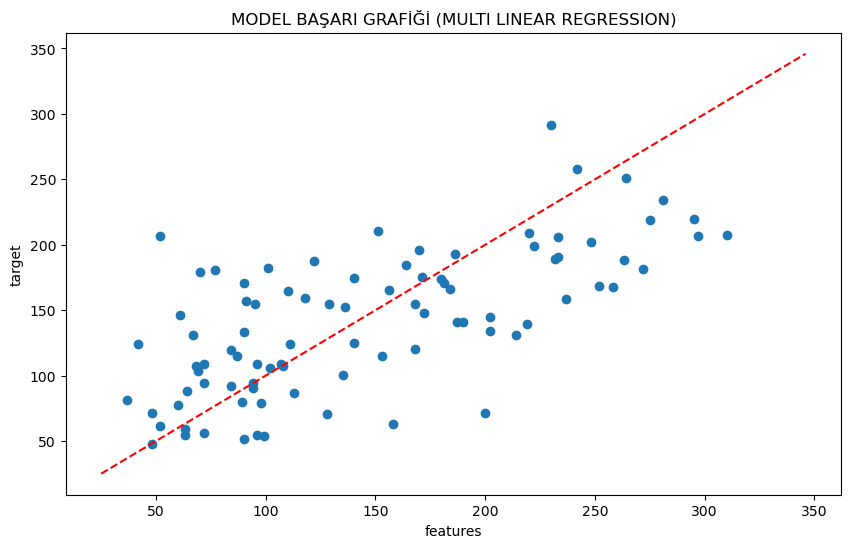

In [29]:
# modelimizin başarısını grafik üzerinde görelim
plt.figure(figsize=(10,6))
plt.plot([y.min(), y.max()],[y.min(), y.max()], 'r--')
plt.scatter(y_test, y_multi_pred)
plt.xlabel("features")
plt.ylabel("target")
plt.title("MODEL BAŞARI GRAFİĞİ (MULTI LINEAR REGRESSION)")
plt.savefig('coklu regresyon basari grafiği.png')
plt.show()

### Polynomial Regression ile Örnek

In [30]:
from sklearn.preprocessing import PolynomialFeatures

In [31]:
X_poly=df[["bmi"]]
y_poly=df["target"]

In [32]:
# Model nesnesi üretme
poly_model=PolynomialFeatures(degree=4)

In [33]:
# Train / Test split (veri bölme)
X_poly_train, X_poly_test, y_poly_train, y_poly_test=train_test_split(X_poly, y_poly, test_size=0.2,random_state=42)

In [34]:
# fit ve transform işlemleri
X_poly_train_transformed= poly_model.fit_transform(X_poly_train)
X_poly_test_transformed= poly_model.transform(X_poly_test)

In [35]:
# Linear regression nesnesi üretme
poly_linear_model=LinearRegression()

In [36]:
# multi linear regresyonumuzu eğitme
poly_linear_model.fit(X_poly_train_transformed, y_poly_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
# Tahmin
y_poly_pred=poly_linear_model.predict(X_poly_test_transformed)

In [38]:
# skorlar
print(f"R2 Score: {r2_score(y_poly_test, y_poly_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_poly_test, y_poly_pred))}")

R2 Score: 0.20233600732379764
RMSE: 65.00880615367548


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


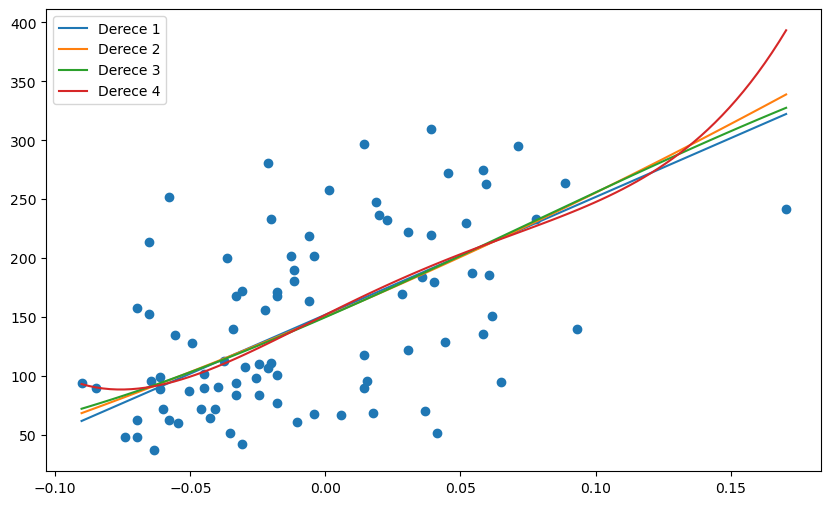

In [43]:
plt.figure(figsize=(10,6))
plt.scatter(X_poly_test, y_poly_test)
x_line=np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1) # reshape(-1,1) -> diyor ki: "kaç satır olduğunu sen hesapla (-1), ama 1 sütun olsun"
for degree in [1,2,3,4]:
    model=PolynomialFeatures(degree=degree)
    # 1. Train verisini dönüştür
    X_train_transformed=model.fit_transform(X_poly_train)
    # 2. x_line'ı dönüştür (grafik için)
    x_line_transformed=model.transform(x_line)
     # 3. Modeli kur ve eğit
    lin = LinearRegression()
    lin.fit(X_train_transformed, y_poly_train)
    # 4. x_line için tahmin yap
    y_line = lin.predict(x_line_transformed)
    
    # 5. Grafiği çiz
    plt.plot(x_line, y_line, label=f'Derece {degree}')
plt.legend()
plt.savefig("farklı_dereceler.png")
plt.show()    